In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Online Retail.xlsx")

print("Dataset loaded:", df.shape)

Dataset loaded: (541909, 8)


In [2]:
df = df.drop_duplicates()

df = df[df["Quantity"] > 0]

df = df[df["UnitPrice"] > 0]

df = df.dropna(subset=["CustomerID"])

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

print("Cleaned data:", df.shape)

Cleaned data: (392692, 9)


In [3]:
cutoff_date = pd.Timestamp("2011-09-01")

historical_data = df[df["InvoiceDate"] < cutoff_date].copy()

future_data = df[df["InvoiceDate"] >= cutoff_date].copy()

print("Historical:", historical_data.shape)
print("Future:", future_data.shape)

Historical: (224036, 9)
Future: (168656, 9)


In [4]:
customer_data = historical_data.groupby("CustomerID").agg({
    "InvoiceDate": ["min", "max"],
    "InvoiceNo": "nunique",
    "Quantity": "sum",
    "TotalAmount": "sum"
})

customer_data.columns = [
    "FirstPurchase",
    "LastPurchase",
    "Frequency",
    "TotalItems",
    "Monetary"
]

customer_data["Recency"] = (
    cutoff_date - customer_data["LastPurchase"]
).dt.days

customer_data["AverageOrderValue"] = (
    customer_data["Monetary"] /
    customer_data["Frequency"]
)

customer_data["Tenure"] = (
    cutoff_date - customer_data["FirstPurchase"]
).dt.days

In [5]:
future_customers = future_data["CustomerID"].unique()

customer_data["RepeatPurchase"] = (
    customer_data.index.isin(future_customers)
).astype(int)

In [6]:
customer_data["RepeatPurchase"].value_counts()

RepeatPurchase
1    1952
0    1365
Name: count, dtype: int64

In [7]:
features = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageOrderValue",
    "TotalItems",
    "Tenure"
]

X = customer_data[features]

y = customer_data["RepeatPurchase"]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (2653, 6)
Testing: (664, 6)


In [9]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Accuracy : 0.634
Precision: 0.6869
Recall   : 0.6957
F1 Score : 0.6912
ROC-AUC  : 0.6956


In [12]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[149 124]
 [119 272]]


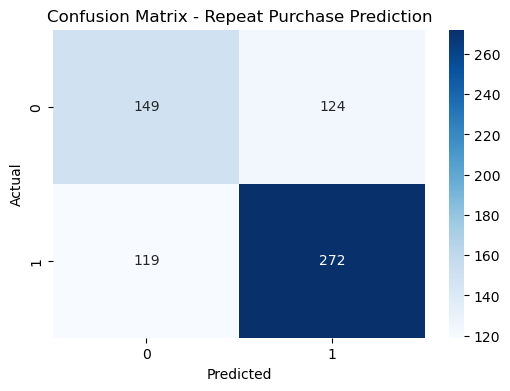

In [13]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Repeat Purchase Prediction")

plt.show()

In [14]:
import joblib

joblib.dump(model, "repeat_purchase_model.pkl")

print("Model saved successfully!")

Model saved successfully!
